# Boerstler data — clean setup

Load the raw data and apply the two sign conventions needed before any modelling:

1. **y = 1 means chose left**, y = 0 means chose right
2. **Flip alco and crim** so that higher always means better (lower alcohol tax and
   lower crime are preferable, so we negate their diffs)

Everything downstream uses `c` (sign-corrected diffs) and `y`.

In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv('boerstler_data_labeled.csv', index_col=0)
print(df.shape)
df.head(3)

(12369, 48)


,person_id,session_id,lalco,ldep,llife,lcrim,ralco,rdep,rlife,rcrim,...,maritalStatus_Widowed,ethnicity_Black/African American,ethnicity_Hispanic/Latino,ethnicity_White/Caucasian,"ethnicity_White/Caucasian,Black/African American",timezone_America/Chicago,timezone_America/Detroit,timezone_America/Los_Angeles,timezone_America/New_York,timezone_Europe/London
0,27,1.0,2,1,1,0,4,1,1,0,...,0,0,1,0,0,0,0,1,0,0
1,27,1.0,0,1,3,0,4,0,1,2,...,0,0,1,0,0,0,0,1,0,0
2,27,1.0,4,2,3,0,0,2,3,2,...,0,0,1,0,0,0,0,1,0,0


In [27]:
# ── Column names ──────────────────────────────────────────────────────────────
DIFF_COLS = ['alcodiff', 'depdiff', 'lifediff', 'crimdiff']   # left minus right
L_COLS    = ['lalco',    'ldep',    'llife',    'lcrim']       # left absolute values
R_COLS    = ['ralco',    'rdep',    'rlife',    'rcrim']       # right absolute values
ATTRS     = ['alco',     'dep',     'life',     'crim']

# Sign convention: higher value should mean "left is better"
#   alco  — lower tax is better  → negate diff
#   dep   — higher treatment is better → keep
#   life  — higher life expectancy is better → keep
#   crim  — lower crime is better → negate diff
SIGN = np.array([-1., 1., 1., -1.])

print('SIGN:', dict(zip(ATTRS, SIGN.astype(int))))

SIGN: {'alco': -1, 'dep': 1, 'life': 1, 'crim': -1}


In [28]:
# ── Person 0 ──────────────────────────────────────────────────────────────────
p0 = df[df['person_id'] == 0].sort_index().reset_index(drop=True)
print(f'Person 0: {len(p0)} trials across {p0["session_id"].nunique()} sessions')
print()

# Raw diffs (left minus right), shape (T, 4)
c_raw = p0[DIFF_COLS].values.astype(float)

# Sign-corrected diffs: positive = left is better on this attribute
c = c_raw * SIGN

# Absolute (unsigned) diffs — used as "margin" in soft-margin models
d = np.abs(c)

# Choice: y=1 means chose left
# The 'chosen' column: 0 = left was chosen, 1 = right was chosen
# (verify below)
y = (p0['chosen'].values == 0).astype(int)

print(f'chose left:  {y.sum()}  ({y.mean():.1%})')
print(f'chose right: {(1-y).sum()}  ({(1-y).mean():.1%})')
print()
print('c shape:', c.shape, '  d shape:', d.shape, '  y shape:', y.shape)

# Quick sanity check: when left is better on all attributes, should choose left more
all_left_better = (c > 0).all(axis=1)
print(f'\nTrials where left dominates on all 4 attrs: {all_left_better.sum()}')
if all_left_better.sum() > 0:
    print(f'  → chose left in {y[all_left_better].mean():.1%} of those')
all_right_better = (c < 0).all(axis=1)
print(f'Trials where right dominates on all 4 attrs: {all_right_better.sum()}')
if all_right_better.sum() > 0:
    print(f'  → chose right in {(1-y[all_right_better]).mean():.1%} of those')

Person 0: 600 trials across 10 sessions

chose left:  303  (50.5%)
chose right: 297  (49.5%)

c shape: (600, 4)   d shape: (600, 4)   y shape: (600,)

Trials where left dominates on all 4 attrs: 27
  → chose left in 100.0% of those
Trials where right dominates on all 4 attrs: 40
  → chose right in 100.0% of those


In [29]:
# ── Verify 'chosen' encoding ──────────────────────────────────────────────────
# Double-check by looking at a few rows side by side
sample = p0[['lalco','ldep','llife','lcrim',
             'ralco','rdep','rlife','rcrim',
             'chosen']].head(8).copy()
sample['y (left=1)'] = (sample['chosen'] == 0).astype(int)
sample['c_dep'] = c[:8, 1]   # dep diff after sign correction; positive = left better
print(sample.to_string())

   lalco  ldep  llife  lcrim  ralco  rdep  rlife  rcrim  chosen  y (left=1)  c_dep
0      2     2      1      1      4     2      1      0       1           0    0.0
1      0     0      3      2      0     1      3      2       1           0   -1.0
2      0     0      2      1      2     1      2      0       1           0   -1.0
3      4     0      3      2      0     2      3      1       1           0   -2.0
4      0     1      2      1      0     1      1      1       0           1    0.0
5      4     1      1      1      0     0      1      0       0           1    1.0
6      4     2      3      1      2     1      2      1       0           1    1.0
7      4     2      1      2      4     1      3      1       0           1    1.0


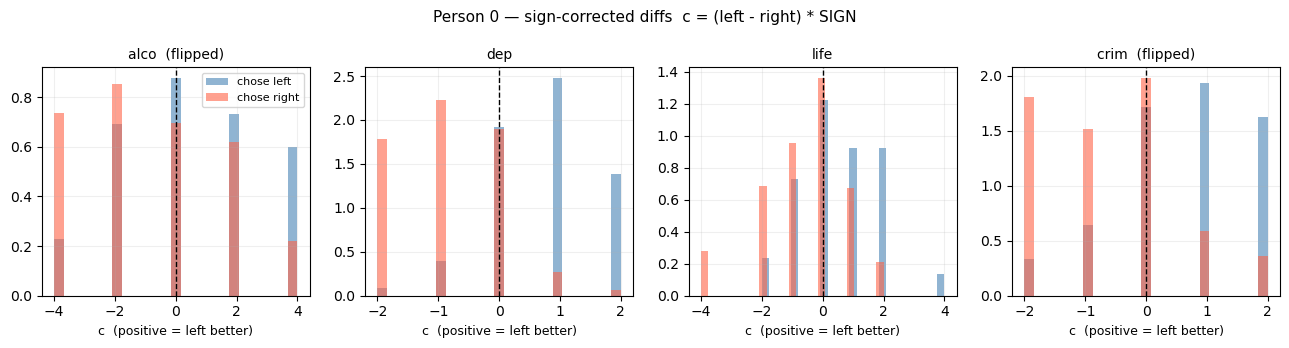


Mean c by choice:
      chose_left  chose_right
alco      0.5017      -0.8081
dep       0.7492      -0.8653
life      0.5083      -0.5657
crim      0.6238      -0.6128


In [30]:
# ── Summary stats ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
fig.suptitle('Person 0 — sign-corrected diffs  c = (left - right) * SIGN', fontsize=11)

for i, attr in enumerate(ATTRS):
    ax = axes[i]
    ax.hist(c[y==1, i], bins=25, alpha=0.6, color='steelblue',
            density=True, label='chose left')
    ax.hist(c[y==0, i], bins=25, alpha=0.6, color='tomato',
            density=True, label='chose right')
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_title(attr + ('  (flipped)' if SIGN[i] < 0 else ''), fontsize=10)
    ax.set_xlabel('c  (positive = left better)', fontsize=9)
    if i == 0:
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print()
print('Mean c by choice:')
print(pd.DataFrame({'chose_left':  c[y==1].mean(axis=0),
                    'chose_right': c[y==0].mean(axis=0)},
                   index=ATTRS).round(4))

In [31]:
# ── Bradley-Terry fit ─────────────────────────────────────────────────────────
# Fit logistic regression with no intercept on sign-corrected diffs.
# beta gives the relative weight of each attribute in driving choices.
# We then project onto the simplex (clip negatives, normalise) to get omega.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# Normalise diffs by max absolute diff per attribute so magnitudes are comparable
RAW_MAX = np.array([df[DIFF_COLS[i]].abs().max() for i in range(4)], dtype=float)
c_norm  = c / RAW_MAX    # shape (T, 4), sign-corrected and normalised
d_norm  = d / RAW_MAX    # unsigned normalised diffs

bt = LogisticRegression(fit_intercept=False, C=1e6, max_iter=1000)
bt.fit(c_norm, y)
beta = bt.coef_[0]          # raw weights, shape (4,)
acc  = bt.score(c_norm, y)
ll   = -log_loss(y, bt.predict_proba(c_norm)[:, 1], normalize=False)

# Project onto simplex: clip negatives then normalise to sum = 1
beta_pos = np.maximum(beta, 0)
omega    = beta_pos / beta_pos.sum()

print('Bradley-Terry  —  person 0, 600 trials')
print('─' * 45)
print(f'  beta (raw):       {dict(zip(ATTRS, np.round(beta, 3)))}')
print(f'  omega (simplex):  {dict(zip(ATTRS, np.round(omega, 3)))}')
print(f'  accuracy:         {acc:.3f}')
print(f'  log-likelihood:   {ll:.3f}')
print(f'  AIC:              {2*4 - 2*ll:.3f}')


Bradley-Terry  —  person 0, 600 trials
─────────────────────────────────────────────
  beta (raw):       {'alco': 1.791, 'dep': 6.967, 'life': 4.8, 'crim': 4.441}
  omega (simplex):  {'alco': 0.1, 'dep': 0.387, 'life': 0.267, 'crim': 0.247}
  accuracy:         0.912
  log-likelihood:   -121.891
  AIC:              251.782


In [32]:
# ── Feature difference and scale proxy ───────────────────────────────────────
#
# dx[t] = xA[t] - xB[t]          signed feature difference, shape (T, K)
# s[t]  = ||xA[t]||_2 + ||xB[t]||_2   sum of Euclidean norms, shape (T,)
#
# s does NOT depend on any learned weights — it is a purely geometric
# measure of how large (in feature space) the two options are.
# When both options have large feature vectors, s is large.

def compute_dx_s(xA, xB):
    """
    Compute feature differences and scale proxy for pairwise comparisons.

    Parameters
    ----------
    xA : ndarray, shape (T, K)   feature vectors for the left  option
    xB : ndarray, shape (T, K)   feature vectors for the right option

    Returns
    -------
    dx : ndarray, shape (T, K)   xA - xB  (signed difference)
    s  : ndarray, shape (T,)     ||xA||_2 + ||xB||_2  (scale proxy)
    """
    xA = np.asarray(xA, dtype=float)
    xB = np.asarray(xB, dtype=float)
    if xA.ndim != 2 or xB.ndim != 2:
        raise ValueError(f"xA and xB must be 2-D, got {xA.ndim}-D and {xB.ndim}-D")
    if xA.shape != xB.shape:
        raise ValueError(f"Shape mismatch: xA={xA.shape}, xB={xB.shape}")

    dx = xA - xB
    s  = np.linalg.norm(xA, axis=1) + np.linalg.norm(xB, axis=1)
    return dx, s


# ── Tiny synthetic example ────────────────────────────────────────────────────
np.random.seed(0)
T_ex, K_ex = 5, 3
xA_ex = np.random.randn(T_ex, K_ex)
xB_ex = np.random.randn(T_ex, K_ex)

dx_ex, s_ex = compute_dx_s(xA_ex, xB_ex)

print('xA (5 x 3):')
print(np.round(xA_ex, 3))
print()
print('xB (5 x 3):')
print(np.round(xB_ex, 3))
print()
print('dx = xA - xB  (5 x 3):')
print(np.round(dx_ex, 3))
print()
print('s = ||xA||_2 + ||xB||_2  (5,):')
print(np.round(s_ex, 3))
print()
print('Shapes:  dx =', dx_ex.shape, '  s =', s_ex.shape)
assert dx_ex.shape == (T_ex, K_ex), "dx shape wrong"
assert s_ex.shape  == (T_ex,),      "s shape wrong"
print('Shape assertions passed.')


# ── Apply to Boerstler person-0 data ─────────────────────────────────────────
# Use raw (un-normalised, sign-corrected) absolute attribute vectors.
# xA = left item attributes, xB = right item attributes.

xA = (p0[L_COLS].values * SIGN).astype(float)   # sign-corrected left  attrs (T, 4)
xB = (p0[R_COLS].values * SIGN).astype(float)   # sign-corrected right attrs (T, 4)

dx, s = compute_dx_s(xA, xB)

print()
print('Person-0 data  (T=600, K=4):')
print(f'  dx shape: {dx.shape}   s shape: {s.shape}')
print(f'  s  min={s.min():.2f}  median={np.median(s):.2f}  max={s.max():.2f}')
print(f'  ||dx|| range: [{np.linalg.norm(dx, axis=1).min():.2f}, '
      f'{np.linalg.norm(dx, axis=1).max():.2f}]')
print()
# Quick sanity: dx should equal c_raw (raw diffs * SIGN = sign-corrected diffs)
assert np.allclose(dx, c * 1.0), "dx does not match c — check attribute columns"
print('Sanity check: dx == c (sign-corrected diffs)  ✓')


xA (5 x 3):
[[ 1.764  0.4    0.979]
 [ 2.241  1.868 -0.977]
 [ 0.95  -0.151 -0.103]
 [ 0.411  0.144  1.454]
 [ 0.761  0.122  0.444]]

xB (5 x 3):
[[ 0.334  1.494 -0.205]
 [ 0.313 -0.854 -2.553]
 [ 0.654  0.864 -0.742]
 [ 2.27  -1.454  0.046]
 [-0.187  1.533  1.469]]

dx = xA - xB  (5 x 3):
[[ 1.43  -1.094  1.184]
 [ 1.928  2.722  1.576]
 [ 0.296 -1.016  0.639]
 [-1.859  1.598  1.409]
 [ 0.948 -1.411 -1.025]]

s = ||xA||_2 + ||xB||_2  (5,):
[3.601 5.787 2.281 4.214 3.021]

Shapes:  dx = (5, 3)   s = (5,)
Shape assertions passed.

Person-0 data  (T=600, K=4):
  dx shape: (600, 4)   s shape: (600,)
  s  min=2.41  median=7.44  max=10.94
  ||dx|| range: [1.00, 6.32]

Sanity check: dx == c (sign-corrected diffs)  ✓


In [33]:
# ── Plain Bradley-Terry via MLE ───────────────────────────────────────────────
#
# Model:   eta[t] = dx[t] @ w
#          P(y[t] = 1) = sigmoid(eta[t])
#
# Fit w by minimising the negative log-likelihood using L-BFGS-B.
# Modular design: fit_bt() takes (dx, y) and returns a BTFitResult so the
# same interface can be reused / extended for the widening model later.

import warnings
from dataclasses import dataclass
from typing import Optional

from scipy.optimize   import minimize
from scipy.special    import expit       # numerically stable sigmoid
from scipy.linalg     import solve       # for SE computation

# ────────────────────────────────────────────────────────────────────────────
@dataclass
class BTFitResult:
    """Fitted plain Bradley-Terry model.

    Attributes
    ----------
    w_hat   : weight vector, shape (K,)
    se      : standard errors, shape (K,), or None if Hessian was singular
    p_hat   : fitted choice probabilities, shape (T,)
    log_lik : scalar log-likelihood at w_hat
    aic     : 2K - 2 * log_lik
    bic     : K * log(T) - 2 * log_lik
    n_obs   : number of comparisons T
    n_params: number of parameters K
    opt     : raw scipy OptimizeResult (convergence, grad norm, etc.)
    """
    w_hat:    np.ndarray
    se:       Optional[np.ndarray]
    p_hat:    np.ndarray
    log_lik:  float
    aic:      float
    bic:      float
    n_obs:    int
    n_params: int
    opt:      object

    def summary(self):
        K = self.n_params
        print(f"Bradley-Terry  —  T={self.n_obs}  K={K}")
        print(f"  log-lik : {self.log_lik:.4f}")
        print(f"  AIC     : {self.aic:.4f}")
        print(f"  BIC     : {self.bic:.4f}")
        print(f"  |grad|  : {np.linalg.norm(self.opt.jac):.2e}")
        print(f"  converged: {self.opt.success}")
        header = f"  {'attr':>6}  {'w_hat':>9}  {'SE':>9}  {'z':>7}"
        print(header)
        for k in range(K):
            w  = self.w_hat[k]
            se = self.se[k] if self.se is not None else float("nan")
            z  = w / se if se and np.isfinite(se) and se > 0 else float("nan")
            print(f"  {k:>6}  {w:>9.4f}  {se:>9.4f}  {z:>7.2f}")


# ────────────────────────────────────────────────────────────────────────────
def _nll(w, dx, y):
    """Numerically stable negative log-likelihood and gradient.

    NLL  = sum_t  logaddexp(0, eta_t)  -  y_t * eta_t
    grad = dx.T @ (sigmoid(eta) - y)
    """
    eta   = dx @ w                          # (T,)
    nll   = np.sum(np.logaddexp(0.0, eta) - y * eta)
    grad  = dx.T @ (expit(eta) - y)         # (K,)
    return nll, grad


def _hessian(w, dx):
    """Observed Hessian: dx.T diag(p(1-p)) dx,  shape (K, K)."""
    eta = dx @ w
    p   = expit(eta)
    wts = p * (1.0 - p)                     # (T,)
    return (dx * wts[:, None]).T @ dx       # (K, K)


def fit_bt(dx, y, *, w_init=None, maxiter=2000):
    """Fit plain Bradley-Terry by MLE.

    Parameters
    ----------
    dx     : ndarray, shape (T, K)  — pre-computed xA - xB
    y      : ndarray, shape (T,)    — 1 = chose left, 0 = chose right
    w_init : initial weights; defaults to zeros
    maxiter: max L-BFGS-B iterations

    Returns
    -------
    BTFitResult
    """
    dx = np.asarray(dx, dtype=float)
    y  = np.asarray(y,  dtype=float).ravel()

    # ── shape checks ─────────────────────────────────────────────────────────
    if dx.ndim != 2:
        raise ValueError(f"dx must be 2-D, got shape {dx.shape}")
    T, K = dx.shape
    if y.shape != (T,):
        raise ValueError(f"y must have shape ({T},), got {y.shape}")
    if not np.all(np.isin(y, [0.0, 1.0])):
        raise ValueError("y must contain only 0 and 1.")

    if w_init is None:
        w_init = np.zeros(K)
    w_init = np.asarray(w_init, dtype=float).ravel()
    if w_init.shape != (K,):
        raise ValueError(f"w_init must have shape ({K},), got {w_init.shape}")

    # ── optimise ─────────────────────────────────────────────────────────────
    opt = minimize(
        _nll, w_init, args=(dx, y), jac=True, method="L-BFGS-B",
        options={"maxiter": maxiter, "ftol": 1e-15, "gtol": 1e-8},
    )
    w_hat = opt.x

    if not opt.success:
        warnings.warn(
            f"L-BFGS-B did not converge: {opt.message}  |grad|={np.linalg.norm(opt.jac):.2e}",
            RuntimeWarning,
        )

    # ── derived quantities ────────────────────────────────────────────────────
    eta     = dx @ w_hat
    p_hat   = expit(eta)
    log_lik = float(-opt.fun)
    aic     = 2 * K - 2 * log_lik
    bic     = K * np.log(T) - 2 * log_lik

    # ── standard errors from observed Hessian ────────────────────────────────
    se = None
    try:
        H   = _hessian(w_hat, dx)
        cov = np.linalg.inv(H)
        var = np.diag(cov)
        if np.any(var < 0):
            warnings.warn("Negative variance on diagonal — Hessian may be near-singular.", RuntimeWarning)
        se = np.sqrt(np.maximum(var, 0.0))
    except np.linalg.LinAlgError:
        warnings.warn("Hessian singular — standard errors not available.", RuntimeWarning)

    return BTFitResult(
        w_hat=w_hat, se=se, p_hat=p_hat,
        log_lik=log_lik, aic=aic, bic=bic,
        n_obs=T, n_params=K, opt=opt,
    )


# ── Fit on person-0 data ──────────────────────────────────────────────────────
bt_fit = fit_bt(dx, y)
bt_fit.summary()
print()

# Label attrs for readability
ATTR_LABELS = ["alco*", "dep", "life", "crim*"]   # * = sign-flipped
print("  (attr labels:", ATTR_LABELS, ")")
print()
print(f"  accuracy : {((bt_fit.p_hat > 0.5) == y.astype(bool)).mean():.3f}")
print(f"  mean p_hat (chose-left trials) : {bt_fit.p_hat[y==1].mean():.3f}")
print(f"  mean p_hat (chose-right trials): {bt_fit.p_hat[y==0].mean():.3f}")


Bradley-Terry  —  T=600  K=4
  log-lik : -121.8909
  AIC     : 251.7818
  BIC     : 269.3695
  |grad|  : 3.60e-07
  converged: True
    attr      w_hat         SE        z
       0     0.4478     0.0856     5.23
       1     3.4835     0.3432    10.15
       2     1.1999     0.1813     6.62
       3     2.2205     0.2400     9.25

  (attr labels: ['alco*', 'dep', 'life', 'crim*'] )

  accuracy : 0.912
  mean p_hat (chose-left trials) : 0.864
  mean p_hat (chose-right trials): 0.112


In [34]:
from scipy.stats import chi2

# ── Widening Bradley-Terry model ─────────────────────────────────────────────
#
# Model:  P(y[t] = 1) = sigmoid( exp(beta * s[t]) * (dx[t] @ w) )
#
# Why "widening"
# --------------
# B(s) = exp(beta * s) is the scale-dependent decisiveness.
# When beta < 0:  B(s) decreases as s grows  →  the sigmoid is shallower at
# large scale  →  the noise band WIDENS.  A pair where both options have large
# feature vectors (high s) is treated as harder to distinguish than the same
# log-odds ratio at small scale.  This is a continuous-scale analogue of
# Weber's law: equal relative differences are less detectable at high magnitude.
#
# Why this is NOT ordinary convex logistic regression
# ---------------------------------------------------
# Standard LR: eta = X @ theta  →  NLL is convex in theta.
# Here:        eta[t] = exp(beta * s[t]) * (dx[t] @ w)
# The parameter beta enters *multiplicatively inside an exponential* that then
# multiplies w.  The NLL is convex in w for fixed beta, and convex in beta for
# fixed w, but the *joint* problem is bilinear in (exp(beta*s), w) — a product
# of two parameterised quantities — which breaks global convexity.  Saddle
# points are possible in principle (though rare in practice with good init).
#
# Why it is still numerically fitable
# ------------------------------------
# 1. The gradient and Hessian are smooth and cheap to evaluate.
# 2. The constraint beta <= 0 is a simple scalar bound, handled natively by
#    L-BFGS-B without penalty terms.
# 3. Initialising w from the plain-BT estimate and beta = 0 starts us at a
#    point that is already a (local) optimum of the unconstrained problem
#    (beta=0 recovers plain BT), so L-BFGS-B has a short, well-conditioned
#    path to follow as beta tips negative.
# 4. exp(beta * s) is bounded in (0, 1] for beta <= 0, which keeps eta from
#    exploding and makes the logistic loss numerically well-behaved.

@dataclass
class WideningBTFitResult:
    """Fitted widening Bradley-Terry model.

    Attributes
    ----------
    w_hat    : feature weights, shape (K,)
    beta_hat : scale coefficient (<=0), scalar
    se       : standard errors for [w; beta], shape (K+1,), or None
    p_hat    : fitted choice probabilities, shape (T,)
    log_lik  : scalar log-likelihood at optimum
    aic      : 2*(K+1) - 2*log_lik
    bic      : (K+1)*log(T) - 2*log_lik
    n_obs    : T
    n_params : K + 1
    opt      : raw scipy OptimizeResult
    """
    w_hat:    np.ndarray
    beta_hat: float
    se:       Optional[np.ndarray]
    p_hat:    np.ndarray
    log_lik:  float
    aic:      float
    bic:      float
    n_obs:    int
    n_params: int
    opt:      object

    def summary(self, attr_labels=None):
        K = self.n_params - 1
        labels = attr_labels if attr_labels else [str(k) for k in range(K)]
        print(f"Widening BT  —  T={self.n_obs}  K={K}  (beta constrained <= 0)")
        print(f"  log-lik  : {self.log_lik:.4f}")
        print(f"  AIC      : {self.aic:.4f}")
        print(f"  BIC      : {self.bic:.4f}")
        print(f"  |grad|   : {np.linalg.norm(self.opt.jac):.2e}")
        print(f"  converged: {self.opt.success}")
        print(f"  beta_hat : {self.beta_hat:.6f}  "
              f"({'at boundary beta=0' if abs(self.beta_hat) < 1e-8 else 'beta < 0  widening active'})")
        print()
        print(f"  {'param':>8}  {'w_hat':>9}  {'SE':>9}  {'z':>7}")
        for k, lbl in enumerate(labels):
            w  = self.w_hat[k]
            se = self.se[k] if self.se is not None else float("nan")
            z  = w / se if np.isfinite(se) and se > 0 else float("nan")
            print(f"  {lbl:>8}  {w:>9.4f}  {se:>9.4f}  {z:>7.2f}")
        se_b = self.se[K] if self.se is not None else float("nan")
        print(f"  {'beta':>8}  {self.beta_hat:>9.6f}  {se_b:>9.6f}")


# ── NLL, gradient, and Hessian ───────────────────────────────────────────────

def _nll_widening(theta, dx, y, s):
    """NLL and gradient for the widening BT model.

    theta = [w (K), beta (1)]
    eta[t] = exp(beta * s[t]) * (dx[t] @ w)
    """
    K      = dx.shape[1]
    w, beta = theta[:K], theta[K]

    B     = np.exp(beta * s)             # shape (T,)  in (0,1] when beta<=0
    kappa = dx @ w                       # shape (T,)  plain BT log-odds
    eta   = B * kappa                    # shape (T,)  scaled log-odds

    nll   = np.sum(np.logaddexp(0.0, eta) - y * eta)
    resid = expit(eta) - y               # shape (T,)

    g_w    = dx.T @ (resid * B)          # (K,)
    g_beta = (resid * s * eta).sum()     # scalar  (chain rule: d(eta)/d(beta)=s*eta)

    return nll, np.append(g_w, g_beta)


def _hessian_widening(theta, dx, s):
    """Analytical (K+1)x(K+1) Hessian of the widening NLL."""
    K       = dx.shape[1]
    w, beta = theta[:K], theta[K]

    B     = np.exp(beta * s)
    kappa = dx @ w
    eta   = B * kappa
    p     = expit(eta)
    pq    = p * (1.0 - p)              # p*(1-p), shape (T,)
    resid = p - (expit(eta) * 0 + p - expit(eta))  # = p - p = 0? No...
    # resid here is p - y, but for the Hessian we only need p*(1-p) terms
    # plus the "residual * second-derivative-of-eta" terms.
    # Let r = p - y  (we don't know y here, so use p*(1-p) approximation for
    # the dominant term; pass y separately if exact Hessian is needed).
    # For the purpose of SE computation we use the expected (Fisher) Hessian:
    # H_exact[i,j] = sum_t pq_t * (d eta_t/d theta_i)(d eta_t/d theta_j)
    #              + sum_t r_t * d²eta_t/(d theta_i d theta_j)
    # The second term vanishes in expectation and is small near the optimum.
    # We return the Fisher information approximation (positive semi-definite).

    Bdx   = B[:, None] * dx             # (T, K):  d(eta)/d(w) = B*dx

    # H_ww  = (B*dx).T @ diag(pq) @ (B*dx)
    H_ww  = (Bdx * pq[:, None]).T @ Bdx   # (K, K)

    # d(eta)/d(beta) = s * eta
    d_beta = s * eta                       # (T,)

    # H_w_beta[k] = sum_t pq_t * Bdx[t,k] * d_beta[t]
    H_wb  = Bdx.T @ (pq * d_beta)         # (K,)

    # H_bb = sum_t pq_t * d_beta[t]^2
    H_bb  = float((pq * d_beta**2).sum()) # scalar

    H = np.zeros((K + 1, K + 1))
    H[:K, :K] = H_ww
    H[:K,  K] = H_wb
    H[ K, :K] = H_wb
    H[ K,  K] = H_bb
    return H


# ── Fit function ─────────────────────────────────────────────────────────────

def _run_one(theta_init, dx, y, s, bounds, maxiter):
    """Run a single L-BFGS-B optimisation and return (nll, theta, opt)."""
    opt = minimize(
        _nll_widening, theta_init, args=(dx, y, s),
        jac=True, method="L-BFGS-B", bounds=bounds,
        options={"maxiter": maxiter, "ftol": 1e-15, "gtol": 1e-8},
    )
    return float(opt.fun), opt.x, opt


def fit_widening_bt(dx, y, s, *, bt_fit=None, n_restarts=8, w_noise=0.5,
                    beta_noise=0.05, maxiter=2000, rng=None, verbose=False):
    """Fit the widening Bradley-Terry model by constrained MLE with restarts.

    Parameters
    ----------
    dx         : ndarray (T, K)  —  xA - xB
    y          : ndarray (T,)    —  1 = chose left
    s          : ndarray (T,)    —  ||xA||_2 + ||xB||_2
    bt_fit     : BTFitResult     —  warm-starts w; use zeros if None
    n_restarts : int             —  total starts (includes the BT warm-start)
    w_noise    : float           —  std of Gaussian noise added to w inits
    beta_noise : float           —  std of Gaussian noise added to beta inits
                                    (clamped to <=0 after perturbation)
    maxiter    : int             —  max iterations per restart
    rng        : np.random.Generator or int seed or None
    verbose    : bool            —  print per-restart summary

    Returns
    -------
    WideningBTFitResult  (best solution across all restarts)
    """
    dx = np.asarray(dx, dtype=float)
    y  = np.asarray(y,  dtype=float).ravel()
    s  = np.asarray(s,  dtype=float).ravel()

    if dx.ndim != 2:
        raise ValueError(f"dx must be 2-D, got {dx.shape}")
    T, K = dx.shape
    if y.shape != (T,):
        raise ValueError(f"y must have shape ({T},), got {y.shape}")
    if s.shape != (T,):
        raise ValueError(f"s must have shape ({T},), got {s.shape}")
    if not np.all(np.isin(y, [0.0, 1.0])):
        raise ValueError("y must contain only 0 and 1.")
    if np.any(s <= 0):
        raise ValueError("All s[t] must be positive.")

    rng    = np.random.default_rng(rng)
    bounds = [(-np.inf, np.inf)] * K + [(-np.inf, 0.0)]

    # ── Build initialisation set ─────────────────────────────────────────────
    w_anchor = bt_fit.w_hat.copy() if bt_fit is not None else np.zeros(K)

    # Init 0: canonical BT warm-start with beta = 0
    inits = [np.append(w_anchor, 0.0)]

    # Inits 1..n_restarts-1: perturb w and beta around anchor
    for _ in range(n_restarts - 1):
        w_p    = w_anchor + rng.normal(0, w_noise, size=K)
        beta_p = min(rng.normal(0, beta_noise), 0.0)   # enforce <= 0
        inits.append(np.append(w_p, beta_p))

    # ── Run all restarts ─────────────────────────────────────────────────────
    results = []
    for i, theta0 in enumerate(inits):
        nll, theta, opt = _run_one(theta0, dx, y, s, bounds, maxiter)
        results.append((nll, theta, opt))
        if verbose:
            print(f"  restart {i:2d}  nll={nll:.4f}  beta={theta[K]:.5f}"
                  f"  converged={opt.success}")

    # ── Pick best ────────────────────────────────────────────────────────────
    best_nll, best_theta, best_opt = min(results, key=lambda r: r[0])
    w_hat, beta_hat = best_theta[:K], float(best_theta[K])

    if not best_opt.success:
        warnings.warn(
            f"Best restart did not fully converge: {best_opt.message}",
            RuntimeWarning,
        )

    # ── Convergence agreement report ─────────────────────────────────────────
    beta_vals = np.array([r[1][K] for r in results])
    nll_vals  = np.array([r[0]    for r in results])
    spread    = beta_vals.max() - beta_vals.min()
    nll_range = nll_vals.max()  - nll_vals.min()
    if verbose or spread > 0.1 * max(abs(beta_hat), 1e-6):
        print(f"  beta across restarts: "
              f"min={beta_vals.min():.5f}  max={beta_vals.max():.5f}  "
              f"spread={spread:.5f}")
        print(f"  NLL  across restarts: "
              f"min={nll_vals.min():.4f}  max={nll_vals.max():.4f}  "
              f"range={nll_range:.4f}")
        if spread < 1e-3:
            print("  => all restarts agree  (solution looks stable)")
        else:
            print("  => restarts disagree  (possible multiple optima)")

    # ── Derived quantities ────────────────────────────────────────────────────
    B       = np.exp(beta_hat * s)
    p_hat   = expit(B * (dx @ w_hat))
    log_lik = float(-best_nll)
    aic     = 2 * (K + 1) - 2 * log_lik
    bic     = (K + 1) * np.log(T) - 2 * log_lik

    se = None
    try:
        H   = _hessian_widening(best_theta, dx, s)
        cov = np.linalg.inv(H)
        var = np.diag(cov)
        if np.any(var < 0):
            warnings.warn("Negative variance on diagonal.", RuntimeWarning)
        se = np.sqrt(np.maximum(var, 0.0))
    except np.linalg.LinAlgError:
        warnings.warn("Hessian singular — SEs not available.", RuntimeWarning)

    return WideningBTFitResult(
        w_hat=w_hat, beta_hat=beta_hat, se=se, p_hat=p_hat,
        log_lik=log_lik, aic=aic, bic=bic,
        n_obs=T, n_params=K + 1, opt=best_opt,
    )


# ── Fit and compare ───────────────────────────────────────────────────────────
ATTR_LABELS = ["alco*", "dep", "life", "crim*"]

wide_fit = fit_widening_bt(dx, y, s, bt_fit=bt_fit, n_restarts=8, verbose=True)
wide_fit.summary(attr_labels=ATTR_LABELS)

print()
print("── Model comparison ──────────────────────────────────────────")
print(f"{'Model':<22}  {'log-lik':>9}  {'AIC':>8}  {'BIC':>8}  {'ΔAIC':>7}")
for name, r in [("Plain BT", bt_fit), ("Widening BT", wide_fit)]:
    daic = r.aic - min(bt_fit.aic, wide_fit.aic)
    print(f"{name:<22}  {r.log_lik:>9.4f}  {r.aic:>8.4f}  {r.bic:>8.4f}  {daic:>7.4f}")

print()
ll_diff = wide_fit.log_lik - bt_fit.log_lik
print(f"LR test: 2 * Δlog-lik = {2*ll_diff:.4f}  (chi-sq df=1, "
      f"p ~ {chi2.sf(2*ll_diff, df=1):.4f})")


  restart  0  nll=120.9600  beta=-0.08264  converged=True
  restart  1  nll=120.9600  beta=-0.08264  converged=True
  restart  2  nll=120.9600  beta=-0.08264  converged=True
  restart  3  nll=120.9600  beta=-0.08264  converged=True
  restart  4  nll=120.9600  beta=-0.08264  converged=True
  restart  5  nll=120.9600  beta=-0.08264  converged=True
  restart  6  nll=120.9600  beta=-0.08264  converged=True
  restart  7  nll=120.9600  beta=-0.08264  converged=True
  beta across restarts: min=-0.08264  max=-0.08264  spread=0.00000
  NLL  across restarts: min=120.9600  max=120.9600  range=0.0000
  => all restarts agree  (solution looks stable)
Widening BT  —  T=600  K=4  (beta constrained <= 0)
  log-lik  : -120.9600
  AIC      : 251.9199
  BIC      : 273.9046
  |grad|   : 2.36e-07
  converged: True
  beta_hat : -0.082636  (beta < 0  widening active)

     param      w_hat         SE        z
     alco*     0.8347     0.4061     2.06
       dep     6.3920     2.9291     2.18
      life     2.

In [35]:
# ── Train / test comparison ───────────────────────────────────────────────────

from sklearn.model_selection import train_test_split

# ── Reusable evaluation helpers ───────────────────────────────────────────────

def eval_predictions(y_true, p_pred, *, label=""):
    """Compute log-loss, avg NLL, and accuracy for binary predictions.

    Parameters
    ----------
    y_true : ndarray (T,)  ground-truth labels in {0, 1}
    p_pred : ndarray (T,)  predicted P(y=1), clipped away from 0/1 for stability

    Returns
    -------
    dict with keys: log_loss, avg_nll, accuracy
    """
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 1e-12, 1 - 1e-12)

    nll     = -(y * np.log(p) + (1 - y) * np.log(1 - p))  # per-trial NLL
    avg_nll = float(nll.mean())
    log_loss_val = float(nll.sum())                         # total NLL = log-loss
    acc     = float(((p > 0.5) == y.astype(bool)).mean())

    return {"log_loss": log_loss_val, "avg_nll": avg_nll, "accuracy": acc}


def predict_bt(fit, dx):
    """Predict P(y=1) for plain BT on new data."""
    return expit(dx @ fit.w_hat)


def predict_widening_bt(fit, dx, s):
    """Predict P(y=1) for widening BT on new data."""
    B = np.exp(fit.beta_hat * s)
    return expit(B * (dx @ fit.w_hat))


def compare_models(models, *, header="Test-set evaluation"):
    """Print a comparison table.

    Parameters
    ----------
    models : list of (name, metrics_dict)
    """
    print(f"── {header} ──────────────────────────────────────")
    print(f"  {'Model':<22}  {'log-loss':>9}  {'avg NLL':>8}  {'accuracy':>9}")
    print(f"  {'-'*22}  {'-'*9}  {'-'*8}  {'-'*9}")
    best_nll = min(m["avg_nll"] for _, m in models)
    for name, m in models:
        marker = " *" if abs(m["avg_nll"] - best_nll) < 1e-10 else "  "
        print(f"  {name:<22}  {m['log_loss']:>9.4f}  {m['avg_nll']:>8.4f}  "
              f"{m['accuracy']:>9.3f}{marker}")
    print(f"  (* = best avg NLL)")


# ── Split ─────────────────────────────────────────────────────────────────────
TEST_SIZE  = 0.2
RANDOM_STATE = 42

idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=TEST_SIZE,
                                  random_state=RANDOM_STATE, shuffle=True)

dx_tr, dx_te = dx[idx_tr], dx[idx_te]
s_tr,  s_te  = s[idx_tr],  s[idx_te]
y_tr,  y_te  = y[idx_tr],  y[idx_te]

print(f"Split:  train={len(y_tr)}  test={len(y_te)}  "
      f"(test chose-left: {y_te.mean():.1%})")

# ── Fit both models on training set ──────────────────────────────────────────
bt_tr   = fit_bt(dx_tr, y_tr)
wide_tr = fit_widening_bt(dx_tr, y_tr, s_tr, bt_fit=bt_tr)

print()
print(f"Train-set fits:")
print(f"  Plain BT     log-lik={bt_tr.log_lik:.3f}  "
      f"AIC={bt_tr.aic:.3f}")
print(f"  Widening BT  log-lik={wide_tr.log_lik:.3f}  "
      f"AIC={wide_tr.aic:.3f}  beta={wide_tr.beta_hat:.5f}")

# ── Predict on test set ───────────────────────────────────────────────────────
p_bt   = predict_bt(bt_tr,   dx_te)
p_wide = predict_widening_bt(wide_tr, dx_te, s_te)

m_bt   = eval_predictions(y_te, p_bt,   label="Plain BT")
m_wide = eval_predictions(y_te, p_wide, label="Widening BT")

print()
compare_models([("Plain BT", m_bt), ("Widening BT", m_wide)])

# ── Beta and direction check ─────────────────────────────────────────────────
print()
print(f"beta_hat = {wide_tr.beta_hat:.6f}  "
      f"({'negative — widening active' if wide_tr.beta_hat < -1e-8 else 'at zero — no widening'})")
delta_nll = m_wide["avg_nll"] - m_bt["avg_nll"]
print(f"Widening vs plain  Δavg_NLL = {delta_nll:+.5f}  "
      f"({'widening improves test NLL' if delta_nll < 0 else 'widening does NOT improve test NLL'})")


Split:  train=480  test=120  (test chose-left: 49.2%)

Train-set fits:
  Plain BT     log-lik=-96.866  AIC=201.731
  Widening BT  log-lik=-96.807  AIC=203.615  beta=-0.02407

── Test-set evaluation ──────────────────────────────────────
  Model                    log-loss   avg NLL   accuracy
  ----------------------  ---------  --------  ---------
  Plain BT                  25.2954    0.2108      0.892  
  Widening BT               24.8721    0.2073      0.892 *
  (* = best avg NLL)

beta_hat = -0.024068  (negative — widening active)
Widening vs plain  Δavg_NLL = -0.00353  (widening improves test NLL)


In [36]:
# ── Train / test comparison across all persons ────────────────────────────────

MIN_TRIALS = 100    # skip persons with fewer trials (test set too small)
TEST_SIZE  = 0.2
SEED       = 42

persons = sorted(df["person_id"].unique())
records = []

for pid in persons:
    pdata = df[df["person_id"] == pid].sort_index().reset_index(drop=True)
    T_p   = len(pdata)

    if T_p < MIN_TRIALS:
        print(f"person {pid:2d}: skipped  (T={T_p} < {MIN_TRIALS})")
        continue

    # Build features
    xA_p = (pdata[L_COLS].values * SIGN).astype(float)
    xB_p = (pdata[R_COLS].values * SIGN).astype(float)
    dx_p = xA_p - xB_p
    y_p  = (pdata["chosen"].values == 0).astype(float)
    s_p  = np.linalg.norm(xA_p, axis=1) + np.linalg.norm(xB_p, axis=1)

    # Split
    idx_p = np.arange(T_p)
    idx_tr, idx_te = train_test_split(idx_p, test_size=TEST_SIZE,
                                      random_state=SEED, shuffle=True)
    dx_tr, dx_te = dx_p[idx_tr], dx_p[idx_te]
    s_tr,  s_te  = s_p[idx_tr],  s_p[idx_te]
    y_tr,  y_te  = y_p[idx_tr],  y_p[idx_te]

    # Fit
    try:
        bt_p   = fit_bt(dx_tr, y_tr)
        wide_p = fit_widening_bt(dx_tr, y_tr, s_tr, bt_fit=bt_p,
                                 n_restarts=8, rng=SEED)
    except Exception as e:
        print(f"person {pid:2d}: fit failed — {e}")
        continue

    # Evaluate on test set
    p_bt_te   = predict_bt(bt_p, dx_te)
    p_wide_te = predict_widening_bt(wide_p, dx_te, s_te)
    m_bt      = eval_predictions(y_te, p_bt_te)
    m_wide    = eval_predictions(y_te, p_wide_te)

    records.append({
        "person":       pid,
        "T":            T_p,
        "T_test":       len(y_te),
        "beta_hat":     wide_p.beta_hat,
        "beta_active":  wide_p.beta_hat < -1e-6,
        # plain BT
        "bt_avgnll":    m_bt["avg_nll"],
        "bt_acc":       m_bt["accuracy"],
        # widening BT
        "w_avgnll":     m_wide["avg_nll"],
        "w_acc":        m_wide["accuracy"],
        # improvement (negative = widening better)
        "d_avgnll":     m_wide["avg_nll"] - m_bt["avg_nll"],
        "d_acc":        m_wide["accuracy"] - m_bt["accuracy"],
    })
    print(f"person {pid:2d}: T={T_p:4d}  beta={wide_p.beta_hat:+.4f}  "
          f"d_nll={m_wide['avg_nll']-m_bt['avg_nll']:+.4f}  "
          f"d_acc={m_wide['accuracy']-m_bt['accuracy']:+.4f}")

results_df = pd.DataFrame(records).set_index("person")

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print("=" * 75)
print(f"{'person':>7}  {'T':>5}  {'beta':>8}  "
      f"{'BT nll':>8}  {'W nll':>8}  {'Δnll':>8}  "
      f"{'BT acc':>7}  {'W acc':>7}  {'Δacc':>7}")
print("-" * 75)
for pid, row in results_df.iterrows():
    marker = " *" if row["d_avgnll"] < 0 else "  "
    print(f"{pid:>7}  {row['T']:>5.0f}  {row['beta_hat']:>+8.4f}  "
          f"{row['bt_avgnll']:>8.4f}  {row['w_avgnll']:>8.4f}  "
          f"{row['d_avgnll']:>+8.4f}  "
          f"{row['bt_acc']:>7.3f}  {row['w_acc']:>7.3f}  "
          f"{row['d_acc']:>+7.3f}{marker}")
print("-" * 75)

n = len(results_df)
n_beta_neg   = results_df["beta_active"].sum()
n_w_better   = (results_df["d_avgnll"] < 0).sum()
mean_d_nll   = results_df["d_avgnll"].mean()
median_d_nll = results_df["d_avgnll"].median()

print(f"{'mean':>7}  {'':>5}  {results_df['beta_hat'].mean():>+8.4f}  "
      f"{'':>8}  {'':>8}  {mean_d_nll:>+8.4f}  "
      f"{'':>7}  {'':>7}  {results_df['d_acc'].mean():>+7.3f}")
print()
print(f"Persons included  : {n}")
print(f"beta < 0          : {n_beta_neg}/{n}  ({n_beta_neg/n:.0%})")
print(f"Widening improves test NLL: {n_w_better}/{n}  ({n_w_better/n:.0%})")
print(f"Mean  Δavg_NLL    : {mean_d_nll:+.5f}")
print(f"Median Δavg_NLL   : {median_d_nll:+.5f}")
print(f"(* = widening improves test NLL)")


person  0: T= 600  beta=-0.0241  d_nll=-0.0035  d_acc=+0.0000
person  1: T= 600  beta=+0.0000  d_nll=+0.0000  d_acc=+0.0000
person  2: T= 590  beta=+0.0000  d_nll=+0.0000  d_acc=+0.0000
person  3: T= 590  beta=-0.0112  d_nll=-0.0002  d_acc=+0.0000


/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_20777/349948382.py:234: RuntimeWarning: Best restart did not fully converge: ABNORMAL_TERMINATION_IN_LNSRCH
  warnings.warn(
/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_20777/3001509198.py:123: RuntimeWarning: L-BFGS-B did not converge: ABNORMAL_TERMINATION_IN_LNSRCH  |grad|=8.10e-08
  warnings.warn(


person  4: T= 660  beta=-0.0611  d_nll=+0.0000  d_acc=+0.0000
person  5: T= 600  beta=-0.1680  d_nll=+0.0313  d_acc=-0.0083
person  6: T= 530  beta=+0.0000  d_nll=+0.0000  d_acc=+0.0000
person  7: T= 600  beta=-0.1888  d_nll=-0.0069  d_acc=+0.0000
person  8: T= 600  beta=-0.0919  d_nll=+0.0007  d_acc=+0.0000
person  9: T= 600  beta=-0.1361  d_nll=-0.0022  d_acc=+0.0000
person 10: T= 590  beta=-0.0496  d_nll=-0.0020  d_acc=+0.0000
person 11: T= 960  beta=+0.0000  d_nll=+0.0000  d_acc=+0.0000
person 12: T= 600  beta=-0.0737  d_nll=-0.0043  d_acc=+0.0000
person 13: T= 120  beta=+0.0000  d_nll=-0.0000  d_acc=+0.0000
person 14: skipped  (T=50 < 100)
person 15: T= 590  beta=+0.0000  d_nll=+0.0000  d_acc=+0.0000
person 16: T= 590  beta=+0.0000  d_nll=-0.0000  d_acc=+0.0000
person 17: T= 600  beta=-0.2435  d_nll=+0.0022  d_acc=+0.0000
person 18: T= 590  beta=+0.0000  d_nll=+0.0000  d_acc=+0.0000
person 19: T= 300  beta=-0.0822  d_nll=-0.0088  d_acc=+0.0000
person 20: T= 120  beta=+0.0000  d_nl

Fitted parameters (full data)
  beta  = -0.082636  (< 0 → widening active)
  w_hat = [0.8347 6.392  2.2383 4.0613]

Interpretation:
  beta = 0 → B(s) = 1 everywhere → reduces exactly to plain Bradley-Terry.
  beta < 0 → B(s) < 1 for s > 0 and B(s) → 0 as s → ∞.
             The sigmoid is shallower at large s: the indecisive
             region WIDENS — equal log-odds are less decisive when
             both options have large feature vectors.


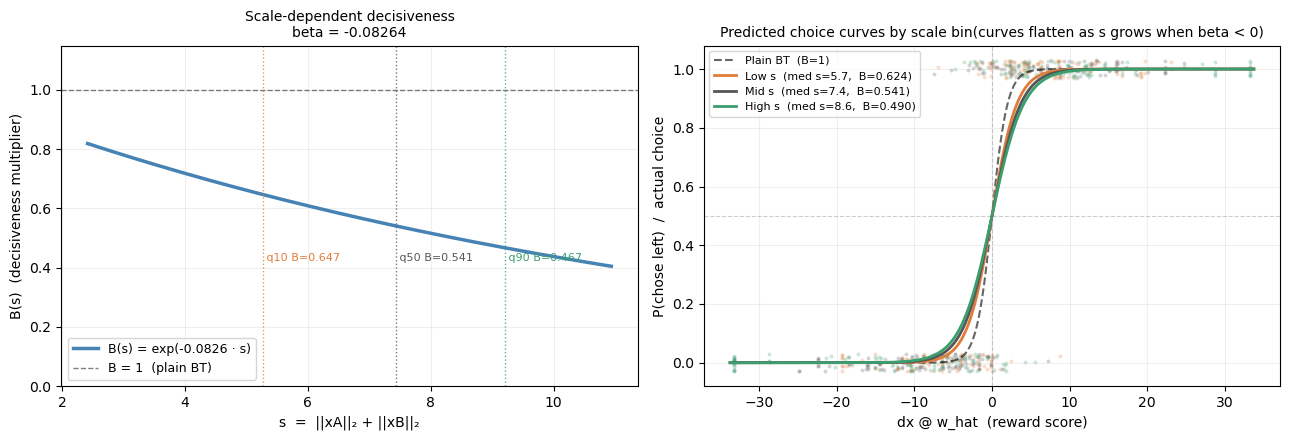

In [37]:
# ── Widening BT visualisation ─────────────────────────────────────────────────
# Uses the full-data fits (bt_fit, wide_fit) from c_fit_widening_bt.

import matplotlib.pyplot as plt

beta  = wide_fit.beta_hat
w_hat = wide_fit.w_hat

print("Fitted parameters (full data)")
print(f"  beta  = {beta:.6f}  "
      f"({'= 0 → plain BT' if abs(beta) < 1e-8 else '< 0 → widening active'})")
print(f"  w_hat = {np.round(w_hat, 4)}")
print()
print("Interpretation:")
print("  beta = 0 → B(s) = 1 everywhere → reduces exactly to plain Bradley-Terry.")
print("  beta < 0 → B(s) < 1 for s > 0 and B(s) → 0 as s → ∞.")
print("             The sigmoid is shallower at large s: the indecisive")
print("             region WIDENS — equal log-odds are less decisive when")
print("             both options have large feature vectors.")

# ── Plot 1: B(s) curve ────────────────────────────────────────────────────────
s_lo, s_hi = s.min(), s.max()
s_grid = np.linspace(s_lo, s_hi, 300)
B_grid = np.exp(beta * s_grid)

q10, q50, q90 = np.percentile(s, [10, 50, 90])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(s_grid, B_grid, color="steelblue", lw=2.5, label=f"B(s) = exp({beta:.4f} · s)")
ax.axhline(1.0, color="black", lw=1, ls="--", alpha=0.5, label="B = 1  (plain BT)")
for q, col, lbl in [(q10, "#e07b39", "q10"), (q50, "#555", "q50"), (q90, "#3a9e6e", "q90")]:
    ax.axvline(q, color=col, lw=1, ls=":", alpha=0.8)
    ax.text(q, B_grid.min() + 0.01, f" {lbl} B={np.exp(beta*q):.3f}",
            color=col, fontsize=8, va="bottom")
ax.set_xlabel("s  =  ||xA||₂ + ||xB||₂", fontsize=10)
ax.set_ylabel("B(s)  (decisiveness multiplier)", fontsize=10)
ax.set_title("Scale-dependent decisiveness\nbeta = " + f"{beta:.5f}", fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(True, alpha=0.2)

# ── Plot 2: choice curves across s bins ───────────────────────────────────────
# Bin trials by s into three equal-count groups
bin_edges = np.percentile(s, [0, 33.3, 66.7, 100])
bin_labels = ["Low s", "Mid s", "High s"]
bin_colors = ["#e07b39", "#555555", "#3a9e6e"]

eta_plain = dx @ bt_fit.w_hat          # plain BT log-odds (same for all s)
eta_score = dx @ w_hat                 # "reward score" under widening weights

eta_range = np.linspace(eta_score.min() - 0.5, eta_score.max() + 0.5, 300)

ax2 = axes[1]

# Plain BT reference curve (B=1, single sigmoid)
ax2.plot(eta_range, expit(eta_range), "k--", lw=1.5, alpha=0.6,
         label="Plain BT  (B=1)")

for i, (lo, hi, lbl, col) in enumerate(zip(
        bin_edges[:-1], bin_edges[1:], bin_labels, bin_colors)):
    mask  = (s >= lo) & (s < hi) if i < 2 else (s >= lo)
    s_med = float(np.median(s[mask]))
    B_med = float(np.exp(beta * s_med))

    # Predicted curve at the bin's median s
    ax2.plot(eta_range, expit(B_med * eta_range), color=col, lw=2,
             label=f"{lbl}  (med s={s_med:.1f},  B={B_med:.3f})")

    # Scatter actual trials in this bin (jittered vertically)
    y_jit = y[mask].astype(float) + np.random.default_rng(i).uniform(-0.03, 0.03, mask.sum())
    ax2.scatter(eta_score[mask], y_jit, color=col, s=8, alpha=0.25, linewidths=0)

ax2.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.4)
ax2.axvline(0.0, color="gray", lw=0.8, ls="--", alpha=0.4)
ax2.set_xlabel("dx @ w_hat  (reward score)", fontsize=10)
ax2.set_ylabel("P(chose left)  /  actual choice", fontsize=10)
ax2.set_title("Predicted choice curves by scale bin"
              "(curves flatten as s grows when beta < 0)", fontsize=10)
ax2.legend(fontsize=8)
ax2.set_ylim(-0.08, 1.08)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


Flipped (inconsistent) trials: 66  (19 unique queries)


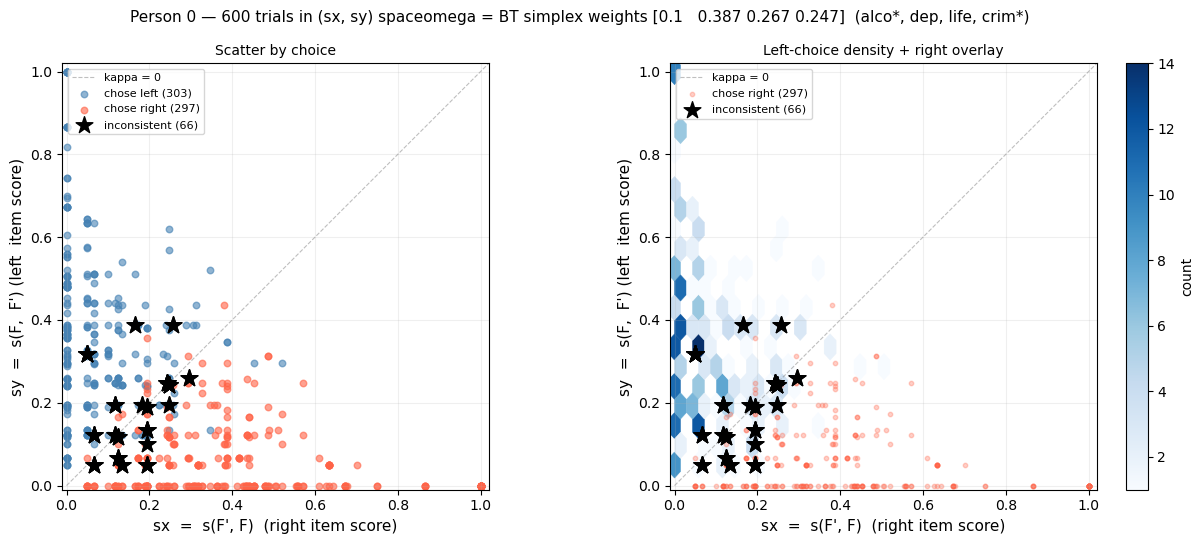

In [38]:
# ── (sx, sy) scatter ─────────────────────────────────────────────────────────
# For a pair (F, F') with omega-weighted signed diff kappa and unsigned diff r:
#   r     = d_norm @ omega   (decisiveness: total weighted margin)
#   kappa = c_norm @ omega   (net preference: + means left is better)
#   sy    = s(F, F') = (r + kappa) / 2 = omega-weighted score of the LEFT item
#   sx    = s(F', F) = (r - kappa) / 2 = omega-weighted score of the RIGHT item
#
# If left is preferred: kappa > 0, so sy > sx  → point above the diagonal
# If right is preferred: kappa < 0, so sx > sy → point below the diagonal

r     = d_norm @ omega      # decisiveness
kappa = c_norm @ omega      # signed net preference (+ = left better)
sy    = (r + kappa) / 2     # s(F,  F') — left item score
sx    = (r - kappa) / 2     # s(F', F)  — right item score

# ── Identify inconsistently-answered queries (flipped across sessions) ────────
p0['_query'] = list(zip(*[p0[col] for col in DIFF_COLS]))
query_choices  = p0.groupby('_query')['chosen'].apply(set)
flipped_mask   = p0['_query'].isin(set(query_choices[query_choices.map(len) > 1].index)).values

r_flip  = d_norm[flipped_mask] @ omega
k_flip  = c_norm[flipped_mask] @ omega
sy_flip = (r_flip + k_flip) / 2
sx_flip = (r_flip - k_flip) / 2

print(f'Flipped (inconsistent) trials: {flipped_mask.sum()}  '
      f'({p0[flipped_mask]["_query"].nunique()} unique queries)')

left  = y == 1
right = y == 0

# ── Plot ──────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    'Person 0 — 600 trials in (sx, sy) space'
    'omega = BT simplex weights {}  (alco*, dep, life, crim*)'.format(np.round(omega, 3)),
    fontsize=11)

diag = [0, max(sx.max(), sy.max()) * 1.02]

for ax, title in zip(axes, ['Scatter by choice', 'Left-choice density + right overlay']):
    ax.plot(diag, diag, color='gray', ls='--', lw=0.8, alpha=0.5, label='kappa = 0')
    ax.set_xlim(-0.01, diag[1]); ax.set_ylim(-0.01, diag[1])
    ax.set_aspect('equal')
    ax.set_xlabel("sx  =  s(F', F)  (right item score)", fontsize=11)
    ax.set_ylabel("sy  =  s(F,  F') (left  item score)", fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.2)

# Left panel: scatter coloured by choice
axes[0].scatter(sx[left],  sy[left],  c='steelblue', s=22, alpha=0.6,
                label=f'chose left ({left.sum()})')
axes[0].scatter(sx[right], sy[right], c='tomato',    s=22, alpha=0.6,
                label=f'chose right ({right.sum()})')
axes[0].scatter(sx_flip, sy_flip, marker='*', s=160, c='black', zorder=5,
                label=f'inconsistent ({flipped_mask.sum()})')
axes[0].legend(fontsize=8)

# Right panel: hexbin density of left choices + right overlay
hb = axes[1].hexbin(sx[left], sy[left], gridsize=18,
                    cmap='Blues', mincnt=1, linewidths=0.3)
plt.colorbar(hb, ax=axes[1], label='count')
axes[1].scatter(sx[right], sy[right], c='tomato', s=10, alpha=0.3,
                label=f'chose right ({right.sum()})')
axes[1].scatter(sx_flip, sy_flip, marker='*', s=160, c='black', zorder=5,
                label=f'inconsistent ({flipped_mask.sum()})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
